In [1]:
from src.Elements import Elements
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
from sklearn.model_selection import train_test_split
from src.EvaluationUtils import EvaluationUtils
import numpy as np

X = np.load("data/training_data/artificial/X_regression_20250906_030758.npy")
y = np.load("data/training_data/artificial/y_regression_20250906_030758.npy")
y /= 4096
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
trainloader = EvaluationUtils.create_dataloader(X_train, y_train, device, 160)
testloader = EvaluationUtils.create_dataloader(X_test, y_test, device, 160)

def get_dataloaders(batch_size=128):
    return EvaluationUtils.create_dataloader(X_train, y_train, device, batch_size), EvaluationUtils.create_dataloader(X_test, y_test, device, batch_size)
print(y[2])


[0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.03974758 0.01897855 0.
 0.03301288 0.         0.00032177 0.         0.1196036 ]


[0.         0.01451672 0.         0.         0.         0.
 0.         0.         0.         0.         0.03232692 0.
 0.         0.         0.         0.         0.00821007]


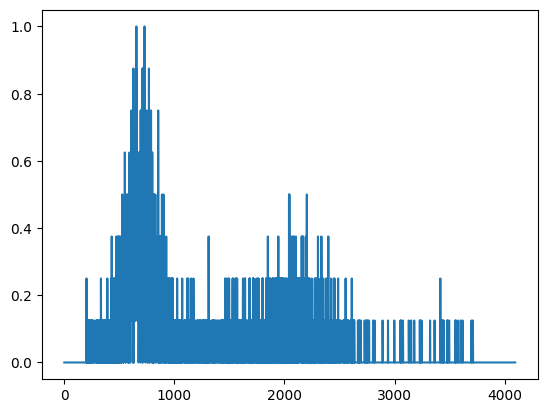

In [3]:
import matplotlib.pyplot as plt 

plt.plot(X[60])
print(y[60])

In [3]:
import wandb 
import optuna
import time 
import torch.optim as optim
import torch.nn as nn
from src.models import create_model
from dataclasses import dataclass, field
from typing import Dict, Any, List, Optional, Callable, Tuple
from contextlib import contextmanager
import traceback
import functools
import os
from datetime import datetime


@dataclass(frozen=True)
class ExperimentConfig:
    project_name: str = "XRFRegression"
    study_name_fmt: str = "{model_name}-regression-study"
    n_trials: int = 150
    epochs: int = 50
    patience: int = 5
    num_outputs: int = 17
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    models_dir: str = "data/model_weights/regression"
    input_seq_len: int = 4096
    models: Tuple[str] = ("resnet1d",)
    output_activations: Tuple[str] = ("none", "sigmoid", "softplus", "tanh_relu")
    batch_size_choices: Tuple[int] = (128,)


def save_model(
    model: torch.nn.Module,
    best_weights: Any,
    cfg: ExperimentConfig,
    model_name: str,
    trial: optuna.Trial,
    run: wandb.sdk.wandb_run.Run
) -> None:
    """
    Load best_weights into `model`, trace (or script) it, save to disk under
    cfg.models_dir/model_name/trial_{n}.pt, and log as a W&B artifact.
    """
    try:
        # Load best weights & eval mode
        if trial is None:
            model.load_state_dict(best_weights)
            model.eval()

            save_dir = os.path.join(cfg.models_dir, model_name)
            os.makedirs(save_dir, exist_ok=True)
            filename = f"trial_{model_name}_{datetime.now()}.pt"
            path = os.path.join(save_dir, filename)

            try:
                torch.save(model, path)
            except RuntimeError as trace_err:
                run.log({"torch_save_err": str(trace_err)})
            return 

        model.load_state_dict(best_weights)
        model.eval()

        save_dir = os.path.join(cfg.models_dir, model_name)
        os.makedirs(save_dir, exist_ok=True)
        filename = f"trial_{model_name}_{trial.number}.pt"
        path = os.path.join(save_dir, filename)

        try:
            torch.save(model, path)
        except RuntimeError as trace_err:
            run.log({"torch_save_err": str(trace_err)})


    except Exception as e:
        err_msg = f"JIT logging failed for trial {trial.number}: {e}"
        print(err_msg)
        traceback.print_exc()
        if run:
            run.log({
                "jit_error": str(e),
                "jit_traceback": traceback.format_exc()
            })

def get_activation(name: str) -> nn.Module:
    return {
        "sigmoid": nn.Sigmoid(),
        "tanh_relu": nn.Sequential(nn.Tanh(), nn.ReLU()),
        "softplus": nn.Softplus(threshold=1),
        "none": nn.Identity(),
    }[name]


def build_model(trial: optuna.Trial, model_name: str, cfg: ExperimentConfig) -> Tuple[nn.Module, Dict]:
    if model_name == "vit":
        embed = trial.suggest_int("embed_dim", 128, 512, step=64)
        num_heads = trial.suggest_categorical("num_heads", [4, 6, 8, 12, 16])

        if embed % num_heads != 0:
            raise optuna.TrialPruned()

        hps = {
            "patch_size": trial.suggest_categorical("patch_size", [64, 128, 256, 512, 1024]),
            "embed_dim": embed,
            "hidden_dim": embed * 4,
            "num_heads": num_heads,
            "num_layers": trial.suggest_int("num_layers", 6, 12),
            "dropout_rate": trial.suggest_float("dropout", 0.0, 0.5, step=0.1),
            "num_outputs": cfg.num_outputs,
        }

        base = create_model("vit", **hps)
    if model_name == "lt_vit":
        embed = trial.suggest_int("embed_dim", 128, 384, step=64)
        num_heads = trial.suggest_categorical("num_heads", [4, 6, 8, 12, 16])

        if embed % num_heads != 0:
            raise optuna.TrialPruned()

        num_layers = trial.suggest_int("num_layers", 6, 16)
        num_lt_layers =  trial.suggest_int("num_lt_layers", 1, 5)

        hps = {
            "patch_size": trial.suggest_categorical("patch_size", [64, 128, 256, 512, 1024]),
            "num_layers": num_layers,
            "num_lt_layers": num_lt_layers,
            "embed_dim": embed,
            "hidden_dim": embed * 4,
            "num_heads": num_heads,
            "dropout_rate": trial.suggest_float("dropout", 0, 0.1, step=0.1),
            "num_outputs": cfg.num_outputs,
        }

        base = create_model("lt_vit", **hps)
    elif model_name == "cnn_vit":
        num_heads = trial.suggest_categorical("num_heads", [4, 8, 16])

        hps = {
            "num_patches": trial.suggest_int("num_patches", 16, 128, step=16),
            "num_heads": num_heads,
            "num_layers": trial.suggest_int("num_layers", 6, 12),
            "dropout_rate": trial.suggest_float("dropout", 0.0, 0.5, step=0.1),
            "num_outputs": cfg.num_outputs,
            "overlapping_conv": trial.suggest_categorical("overlapping_conv", [True, False]),
            "use_gelu": trial.suggest_categorical("use_gelu", [True, False])
        }
        base = create_model("cnn_vit", **hps)
    elif model_name == "xrfnet":

        hps = {
            "num_outputs": 17,
        }
        base = create_model("xrfnet", **hps)
    elif model_name == "resnet1d":

        hps = {
            "num_outputs": 17,
        }
        base = create_model("resnet1d", **hps)
    elif model_name == "mlp":
        base = create_model("mlp", dict())
    else:
        raise ValueError(f"Unsupported model {model_name}")

    act = get_activation(trial.suggest_categorical("output_activation", cfg.output_activations))
    return nn.Sequential(base, act), hps


        # wandb.config.update({"optimizer": optimizer.__class__.__name__, "criterion": crit.__class__.__name__}, allow_val_change=True)
        # wandb.config.update(trial.params, allow_val_change=True)


def objective(trial: optuna.Trial, cfg: ExperimentConfig, model_name: str):
    # 1) W&B setup
    run = wandb.init(
        project=cfg.project_name,
        group=model_name,
        name=f"{model_name}-trial-{trial.number}-{int(time.time())}",
        config=trial.params,
        reinit=True,
    )

    try:
        # 2) Data
        train_dl, val_dl = get_dataloaders(trial.suggest_categorical("batch_size", cfg.batch_size_choices))

        # 3) Model
        model, model_hps = build_model(trial, model_name, cfg)
        model.to(cfg.device)
        wandb.config.update(model_hps, allow_val_change=True)

        # 4) Optimizer & loss
        optimizer = optim.Adam(model.parameters(), lr=trial.suggest_float("lr",1e-4,1e-2, log=True))
        crit =  getattr(nn, trial.suggest_categorical("criterion", ["MSELoss"]))()
        wandb.config.update(trial.params, allow_val_change=True)

        # 5) Train & evaluate
        results = EvaluationUtils.train(
            model, train_dl, val_dl, optimizer, crit, 
            epochs=cfg.epochs, patience=cfg.patience, mode="regression", wandb_run=run
        )
        loss = results["best_valid_loss"]
        wandb.summary["best_valid_loss"] = loss

        # 6) Optional JIT
        if cfg.models_dir and results.get("best_model_weights"):
            save_model(model, results["best_model_weights"], cfg, model_name, trial, run)

        return np.max(results["metric_histories"]["r2_score"])

    except optuna.exceptions.TrialPruned:
        run.summary["status"] = "pruned"
        raise
    except Exception as e:
        run.summary["status"] = "failed"
        run.log({"error": str(e), "traceback": traceback.format_exc()})
        return float('inf')
    finally:
        run.finish()


def main():
    cfg = ExperimentConfig()
    for model_name in cfg.models:
        study = optuna.create_study(
            study_name=cfg.study_name_fmt.format(model_name=model_name),
            direction="maximize",
            sampler=optuna.samplers.TPESampler(),
            storage=f"sqlite:///{model_name}.db",
            load_if_exists=True,
        )
        study.optimize(functools.partial(objective, cfg=cfg, model_name=model_name), n_trials=cfg.n_trials)
        print("Best loss:", study.best_value, "Params:", study.best_params)


# if __name__ == "__main__":
#     main()

In [4]:
import wandb
import time
import torch
import torch.optim as optim
import torch.nn as nn
from src.models import create_model
from dataclasses import dataclass, field
from typing import Dict, Any, Tuple
import traceback
import os
import copy
import numpy as np # Added for the return value of the training function


@dataclass(frozen=True)
class ExperimentConfig:
    """General configuration for the experiment environment."""
    project_name: str = "XRFRegression_SingleRun"
    epochs: int = 50
    patience: int = 5
    num_outputs: int = 17
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    models_dir: str = "data/model_weights/regression"
    input_seq_len: int = 4096

@dataclass(frozen=True)
class TrainingConfig:
    """Configuration for a single model and training run."""
    model_name: str = "resnet1d"
    output_activation: str = "none"
    batch_size: int = 128
    learning_rate: float = 1e-3
    criterion: str = "MSELoss"
    
    # Model-specific hyperparameters.
    # Add or remove parameters based on the chosen `model_name`.
    model_hps: Dict[str, Any] = field(default_factory=lambda: {
        # --- Example for resnet1d or xrfnet ---
        "num_outputs": 17,
        
        # --- Example for vit ---
        # "patch_size": 256,
        # "embed_dim": 256,
        # "hidden_dim": 1024,
        # "num_heads": 8,
        # "num_layers": 6,
        # "dropout_rate": 0.1,
    })



def get_activation(name: str) -> nn.Module:
    """Returns the activation function module based on its name."""
    return {
        "sigmoid": nn.Sigmoid(),
        "tanh_relu": nn.Sequential(nn.Tanh(), nn.ReLU()),
        "softplus": nn.Softplus(threshold=1),
        "none": nn.Identity(),
    }[name]

def build_model(
    model_name: str,
    model_hps: Dict,
    output_activation_name: str,
) -> nn.Module:
    """Builds the model from a name and hyperparameter dictionary."""
    # Ensure num_outputs is in hps for models that need it
    if 'num_outputs' not in model_hps:
        model_hps['num_outputs'] = 17 # Default value
        
    # Basic validation for ViT-like models
    if "vit" in model_name:
        if model_hps.get("embed_dim", 0) % model_hps.get("num_heads", 1) != 0:
            raise ValueError("For ViT models, 'embed_dim' must be divisible by 'num_heads'.")

    base = create_model(model_name, **model_hps)
    activation_layer = get_activation(output_activation_name)
    
    return nn.Sequential(base, activation_layer)


def run_training(exp_cfg: ExperimentConfig, train_cfg: TrainingConfig):
    """
    Executes a single training run based on the provided configurations.
    """
    run_name = f"{train_cfg.model_name}-{int(time.time())}"
    
    # 1) W&B setup
    run = wandb.init(
        project=exp_cfg.project_name,
        group=train_cfg.model_name,
        name=run_name,
        config={**exp_cfg.__dict__, **train_cfg.__dict__},
    )

    try:
        # 2) Data
        train_dl, val_dl = get_dataloaders(train_cfg.batch_size)

        # 3) Model
        print(f"Building model: {train_cfg.model_name} with HPs: {train_cfg.model_hps}")
        model = build_model(
            model_name=train_cfg.model_name,
            model_hps=train_cfg.model_hps,
            output_activation_name=train_cfg.output_activation,
        )
        model.to(exp_cfg.device)

        # 4) Optimizer & Loss
        optimizer = optim.Adam(model.parameters(), lr=train_cfg.learning_rate)
        criterion = getattr(nn, train_cfg.criterion)()

        # 5) Train & Evaluate
        results = EvaluationUtils.train(
            model, train_dl, val_dl, optimizer, criterion,
            epochs=exp_cfg.epochs,
            patience=exp_cfg.patience,
            mode="regression",
            wandb_run=run
        )
        
        loss = results["best_valid_loss"]
        r2_score = np.max(results["metric_histories"]["r2_score"])
        wandb.summary["best_valid_loss"] = loss
        wandb.summary["best_r2_score"] = r2_score
        print(f"Final Results -> Best Valid Loss: {loss:.4f}, Best R2 Score: {r2_score:.4f}")

        # 6) Save the final model
        if exp_cfg.models_dir and results.get("best_model_weights"):
            save_model(
                    model=model,
                    best_weights=results["best_model_weights"],
                    cfg=exp_cfg,
                    model_name=train_cfg.model_name,
                    trial=None,  # Not using Optuna here
                    run=run
            )
        
        run.summary["status"] = "completed"

    except Exception as e:
        print(f"An error occurred during the run: {e}")
        traceback.print_exc()
        if run:
            run.summary["status"] = "failed"
            run.log({"error": str(e), "traceback": traceback.format_exc()})
    finally:
        if run:
            run.finish()

# if __name__ == "__main__":
#     # 1. Define the general experiment configuration
#     experiment_config = ExperimentConfig()

#     # 2. Define the specific training configuration for ONE model
#     #    Simply change the values here to train a different model
#     #    or use different parameters.
#     training_config = TrainingConfig(
#         model_name="resnet1d",
#         output_activation="none",
#         batch_size=128,
#         learning_rate=0.001,
#         criterion="MSELoss",
#         model_hps={
#            "num_outputs": 17,
#         }
#     )
    
    # 3. Start the training run
    # run_training(experiment_config, training_config)

In [5]:
if __name__ == "__main__":
    # 1. Define the general experiment configuration
    experiment_config = ExperimentConfig()

    # 2. Define a list of training configurations for each model
    configs_to_run = [
        
        # --- CNN Configuration (Assuming resnet1d) ---
        TrainingConfig(
            model_name="xrfnet",
            output_activation="tanh_relu",
            batch_size=128,
            learning_rate=0.000128,
            criterion="MSELoss",
            model_hps={
                "num_outputs": 17,
            }
        ),
        
        # --- LT-VIT Configuration ---
        TrainingConfig(
            model_name="lt_vit",
            output_activation="softplus",
            batch_size=128,
            learning_rate=0.00182,
            criterion="MSELoss",
            model_hps={
                "num_outputs": 17,
                "dropout_rate": 0,
                "embed_dim": 192,
                "hidden_dim": 768,
                "num_heads": 12,
                "patch_size": 256,
                "num_layers": 6,
                "num_lt_layers": 3,
            }
        ),
        
        # --- Vanilla ViT Configuration ---
        TrainingConfig(
            model_name="vit",
            output_activation="sigmoid",
            batch_size=128,
            learning_rate=0.00237,
            criterion="MSELoss",
            model_hps={
                "num_outputs": 17,
                "dropout_rate": 0.1,
                "embed_dim": 192,
                "hidden_dim": 768,
                "num_heads": 6,
                "patch_size": 512,
                "num_layers": 8,
            }
        ),
        
        # --- ViT-CNN Configuration ---
        TrainingConfig(
            model_name="cnn_vit",
            output_activation="softplus",
            batch_size=128,
            learning_rate=0.00257,
            criterion="MSELoss",
            model_hps={
                "num_outputs": 17,
                "dropout_rate": 0,
                "num_heads": 16,
                "num_layers": 12,
                "num_patches": 16,
                "overlapping_conv": False,
                "use_gelu": True,
            }
        ),
    ]
    
    # 3. Start the training runs in a loop
    for training_config in configs_to_run:
        print(f"Starting training for model: {training_config.model_name}")
        run_training(experiment_config, training_config)
        print("--------------------------------------------------")

Starting training for model: xrfnet


wandb: Currently logged in as: erykzarebski0 (mind-flayers) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Building model: xrfnet with HPs: {'num_outputs': 17}


2025-09-06 16:38:49,770 - INFO - Starting training process (mode: regression, epochs: 50, patience: 5)
2025-09-06 16:38:49,771 - INFO - --- Epoch 1/50 ---
2025-09-06 16:38:50,313 - INFO -   Batch 10/1758, Loss: 0.0001425
2025-09-06 16:38:50,414 - INFO -   Batch 20/1758, Loss: 0.0001042
2025-09-06 16:38:50,518 - INFO -   Batch 30/1758, Loss: 0.0000870
2025-09-06 16:38:50,615 - INFO -   Batch 40/1758, Loss: 0.0000710
2025-09-06 16:38:50,711 - INFO -   Batch 50/1758, Loss: 0.0000603
2025-09-06 16:38:50,808 - INFO -   Batch 60/1758, Loss: 0.0000454
2025-09-06 16:38:50,905 - INFO -   Batch 70/1758, Loss: 0.0000500
2025-09-06 16:38:51,006 - INFO -   Batch 80/1758, Loss: 0.0000422
2025-09-06 16:38:51,115 - INFO -   Batch 90/1758, Loss: 0.0000380
2025-09-06 16:38:51,221 - INFO -   Batch 100/1758, Loss: 0.0000463
2025-09-06 16:38:51,338 - INFO -   Batch 110/1758, Loss: 0.0000297
2025-09-06 16:38:51,435 - INFO -   Batch 120/1758, Loss: 0.0000331
2025-09-06 16:38:51,530 - INFO -   Batch 130/1758,

Final Results -> Best Valid Loss: 0.0000, Best R2 Score: 0.8271


...

Building model: cnn_vit with HPs: {'num_outputs': 17, 'dropout_rate': 0, 'num_heads': 16, 'num_layers': 12, 'num_patches': 16, 'overlapping_conv': False, 'use_gelu': True}


2025-09-06 17:56:03,705 - INFO -   Batch 10/1758, Loss: 0.0011785
2025-09-06 17:56:04,204 - INFO -   Batch 20/1758, Loss: 0.0003911
2025-09-06 17:56:04,706 - INFO -   Batch 30/1758, Loss: 0.0003516
2025-09-06 17:56:05,136 - INFO -   Batch 40/1758, Loss: 0.0002929
2025-09-06 17:56:05,534 - INFO -   Batch 50/1758, Loss: 0.0002321
2025-09-06 17:56:05,960 - INFO -   Batch 60/1758, Loss: 0.0002932
2025-09-06 17:56:06,356 - INFO -   Batch 70/1758, Loss: 0.0002160
2025-09-06 17:56:06,753 - INFO -   Batch 80/1758, Loss: 0.0002562
2025-09-06 17:56:07,192 - INFO -   Batch 90/1758, Loss: 0.0003031
2025-09-06 17:56:07,549 - INFO -   Batch 100/1758, Loss: 0.0001942
2025-09-06 17:56:07,904 - INFO -   Batch 110/1758, Loss: 0.0002464
2025-09-06 17:56:08,248 - INFO -   Batch 120/1758, Loss: 0.0002278
2025-09-06 17:56:08,582 - INFO -   Batch 130/1758, Loss: 0.0002237
2025-09-06 17:56:08,921 - INFO -   Batch 140/1758, Loss: 0.0002556
2025-09-06 17:56:09,241 - INFO -   Batch 150/1758, Loss: 0.0001983
2025

Final Results -> Best Valid Loss: 0.0000, Best R2 Score: 0.8746


train_loss,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▆▅▅▅▄▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mae,█▇▇▇▆▅▄▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_mse,█▆▅▅▅▄▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_r2_score,▁▁▁▁▂▃▅▆▇▇▇▇████████████████████████████
best_r2_score,0.87461
best_valid_loss,1e-05
status,completed
train_loss,1e-05
val_loss,1e-05
val_mae,0.00143


--------------------------------------------------


In [6]:
if __name__ == "__main__":
    experiment_config = ExperimentConfig()

    configs_to_run = [
        # --- LT-VIT Configuration ---
        TrainingConfig(
            model_name="mlp",
            model_hps={}
        ),
    ]
    
    # 3. Start the training runs in a loop
    for training_config in configs_to_run:
        print(f"Starting training for model: {training_config.model_name}")
        run_training(experiment_config, training_config)
        print("--------------------------------------------------")

Starting training for model: mlp


2025-09-06 19:55:16,869 - INFO - Starting training process (mode: regression, epochs: 50, patience: 5)
2025-09-06 19:55:16,870 - INFO - --- Epoch 1/50 ---
2025-09-06 19:55:16,961 - INFO -   Batch 10/1758, Loss: 0.0003561
2025-09-06 19:55:17,023 - INFO -   Batch 20/1758, Loss: 0.0002417


Building model: mlp with HPs: {}


2025-09-06 19:55:17,083 - INFO -   Batch 30/1758, Loss: 0.0001339
2025-09-06 19:55:17,147 - INFO -   Batch 40/1758, Loss: 0.0001099
2025-09-06 19:55:17,201 - INFO -   Batch 50/1758, Loss: 0.0000921
2025-09-06 19:55:17,244 - INFO -   Batch 60/1758, Loss: 0.0000935
2025-09-06 19:55:17,287 - INFO -   Batch 70/1758, Loss: 0.0000874
2025-09-06 19:55:17,332 - INFO -   Batch 80/1758, Loss: 0.0000656
2025-09-06 19:55:17,372 - INFO -   Batch 90/1758, Loss: 0.0000616
2025-09-06 19:55:17,415 - INFO -   Batch 100/1758, Loss: 0.0000501
2025-09-06 19:55:17,458 - INFO -   Batch 110/1758, Loss: 0.0000690
2025-09-06 19:55:17,502 - INFO -   Batch 120/1758, Loss: 0.0000683
2025-09-06 19:55:17,544 - INFO -   Batch 130/1758, Loss: 0.0000507
2025-09-06 19:55:17,586 - INFO -   Batch 140/1758, Loss: 0.0000545
2025-09-06 19:55:17,631 - INFO -   Batch 150/1758, Loss: 0.0000415
2025-09-06 19:55:17,675 - INFO -   Batch 160/1758, Loss: 0.0000451
2025-09-06 19:55:17,717 - INFO -   Batch 170/1758, Loss: 0.0000393
20

Final Results -> Best Valid Loss: 0.0000, Best R2 Score: 0.8552


train_loss,█▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▇▇▄▅▇▃▃▃▃▃▂▃▂▃▁▁▂▂▂▂
val_mae,█▇▇▅▅▇▃▃▄▃▄▃▄▂▃▁▁▂▃▂▂
val_mse,█▇▇▄▅▇▂▃▃▃▃▂▃▂▃▁▁▂▂▂▂
val_r2_score,▁▃▂▅▃▂▆▆▆▆▆▇▆▇▅███▇▇▇
best_r2_score,0.85521
best_valid_loss,2e-05
status,completed
train_loss,1e-05
val_loss,2e-05
val_mae,0.00175


--------------------------------------------------
